## 🚚 Food Delivery Time Prediction
Predicting restaurant-to-customer delivery time using machine learning.

Dataset: Kaggle — 45,593 training records, 11,399 test records  
Target: `Time_taken(min)` — delivery time in minutes (range: 10–54 mins)  
Best Model: XGBoost (Tuned) — R² = 0.81, MAE = 3.23 mins, RMSE = 4.04 mins

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('train.csv', dtype_backend='numpy_nullable', engine='python')
test_df  = pd.read_csv('test.csv',  dtype_backend='numpy_nullable', engine='python')

# Convert StringArray to plain object dtype
for col in train_df.select_dtypes(include='string').columns:
    train_df[col] = train_df[col].astype(object)
for col in test_df.select_dtypes(include='string').columns:
    test_df[col] = test_df[col].astype(object)

print("✅ Loaded:", train_df.shape, test_df.shape)

✅ Loaded: (45593, 20) (11399, 19)


## 2. Data Cleaning
Whitespace stripping, NaN normalization, and fixing the `Weatherconditions` prefix.

In [2]:
# Strip whitespace
for col in train_df.select_dtypes(include='object').columns:
    train_df[col] = train_df[col].str.strip()
for col in test_df.select_dtypes(include='object').columns:
    test_df[col] = test_df[col].str.strip()

# Replace text NaNs with real NaN
nan_strings = ['NaN', 'nan', 'none', 'None', 'NULL', 'null', 'NA', 'N/A', '']
train_df.replace(nan_strings, np.nan, inplace=True)
test_df.replace(nan_strings, np.nan, inplace=True)

# Fix Weatherconditions prefix
train_df['Weatherconditions'] = train_df['Weatherconditions'].str.replace('conditions ', '', regex=False)
test_df['Weatherconditions']  = test_df['Weatherconditions'].str.replace('conditions ', '', regex=False)

# Fix remaining NaN string in Weatherconditions
train_df['Weatherconditions'] = train_df['Weatherconditions'].replace('NaN', np.nan)
test_df['Weatherconditions']  = test_df['Weatherconditions'].replace('NaN', np.nan)

# Fix numeric columns
for col in ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
    test_df[col]  = pd.to_numeric(test_df[col],  errors='coerce')

print("✅ Cleaned!")
print("Traffic:", train_df['Road_traffic_density'].unique())
print("City:   ", train_df['City'].unique())
print("Weather:", train_df['Weatherconditions'].unique())

✅ Cleaned!
Traffic: ['High' 'Jam' 'Low' 'Medium' nan]
City:    ['Urban' 'Metropolitian' 'Semi-Urban' nan]
Weather: ['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' nan]


In [3]:
train_df['Time_taken(min)'] = (train_df['Time_taken(min)']
                                .astype(str)
                                .str.extract(r'(\d+)')
                                .astype(float))
print("✅ Target:", train_df['Time_taken(min)'].describe())

✅ Target: count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64


## 3. Feature Engineering 

## 3.1 Time Features
Extracting order hour, pickup hour, pickup delay, and rush hour flag.


In [4]:
for df in [train_df, test_df]:
    df['order_hour']   = pd.to_datetime(df['Time_Orderd'],       format='%H:%M:%S', errors='coerce').dt.hour
    df['pickup_hour']  = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce').dt.hour
    df['pickup_delay'] = (df['pickup_hour'] - df['order_hour']) * 60
    df['pickup_delay'] = df['pickup_delay'].apply(lambda x: x + 1440 if x < 0 else x)
    df['is_rush_hour'] = df['order_hour'].apply(
        lambda h: 1 if pd.notna(h) and (7 <= h <= 9 or 18 <= h <= 21) else 0
    )

for col in ['order_hour', 'pickup_hour', 'pickup_delay']:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col]  = test_df[col].fillna(median_val)

print("✅ Time features done")
print(train_df[['order_hour','pickup_hour','pickup_delay']].head())

✅ Time features done
   order_hour  pickup_hour  pickup_delay
0        11.0           11           0.0
1        19.0           19           0.0
2         8.0            8           0.0
3        18.0           18           0.0
4        13.0           13           0.0


In [5]:
train_df['Order_Date'] = pd.to_datetime(train_df['Order_Date'], dayfirst=True)
test_df['Order_Date']  = pd.to_datetime(test_df['Order_Date'],  dayfirst=True)

for df in [train_df, test_df]:
    df['order_day']     = df['Order_Date'].dt.day
    df['order_month']   = df['Order_Date'].dt.month
    df['order_weekday'] = df['Order_Date'].dt.dayofweek
    df['is_weekend']    = df['order_weekday'].isin([5, 6]).astype(int)

print("✅ Date features done")

✅ Date features done


## 3.2 Distance Feature
Calculating straight-line distance using the **Haversine formula** from restaurant coordinates to delivery location.

In [6]:
for col in ['Restaurant_latitude', 'Restaurant_longitude',
            'Delivery_location_latitude', 'Delivery_location_longitude']:
    train_df[col] = train_df[col].apply(lambda x: np.nan if pd.notna(x) and abs(x) < 1 else x)
    test_df[col]  = test_df[col].apply(lambda x: np.nan if pd.notna(x) and abs(x) < 1 else x)

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

for df in [train_df, test_df]:
    df['distance_km'] = haversine_distance(
        df['Restaurant_latitude'],  df['Restaurant_longitude'],
        df['Delivery_location_latitude'], df['Delivery_location_longitude']
    )
    df['distance_km'] = df['distance_km'].clip(upper=50)

print("✅ Distance done:", train_df['distance_km'].describe())

✅ Distance done: count    41953.000000
mean        10.133940
std          6.897014
min          1.465067
25%          4.658001
50%          9.220368
75%         13.760880
max         50.000000
Name: distance_km, dtype: float64


In [7]:
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries',
                'Restaurant_latitude', 'Restaurant_longitude',
                'Delivery_location_latitude', 'Delivery_location_longitude', 'distance_km']

for col in numeric_cols:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col]  = test_df[col].fillna(median_val)

cat_fill_cols = ['Weatherconditions', 'Road_traffic_density', 'Festival', 'City']
for col in cat_fill_cols:
    mode_val = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mode_val)
    test_df[col]  = test_df[col].fillna(mode_val)

print("✅ NaNs in train:", train_df.isnull().sum().sum())
print("✅ NaNs in test: ", test_df.isnull().sum().sum())

✅ NaNs in train: 1731
✅ NaNs in test:  444


## 3.3 Encoding
- Ordinal encoding for traffic density (Low→Medium→High→Jam) and weather severity  
- Label encoding for order type, vehicle type, festival flag

In [8]:
# Ordinal encoding (order matters)
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
weather_map = {'Sunny': 0, 'Cloudy': 1, 'Windy': 2, 'Fog': 3, 'Sandstorms': 4, 'Stormy': 5}
city_map    = {'Semi-Urban': 0, 'Urban': 1, 'Metropolitian': 2}

for df in [train_df, test_df]:
    df['Road_traffic_density'] = df['Road_traffic_density'].map(traffic_map)
    df['Weatherconditions']    = df['Weatherconditions'].map(weather_map)
    df['City']                 = df['City'].map(city_map)

# Label encoding
le = LabelEncoder()
for col in ['Type_of_order', 'Type_of_vehicle', 'Festival']:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))

print("✅ Encoding done!")
print("Traffic:", sorted(train_df['Road_traffic_density'].unique()))
print("Weather:", sorted(train_df['Weatherconditions'].unique()))
print("City:   ", sorted(train_df['City'].unique()))

✅ Encoding done!
Traffic: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Weather: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
City:    [np.int64(0), np.int64(1), np.int64(2)]


## 4. Train/Test Split & Scaling
80/20 split — 36,474 training samples, 9,119 test samples.  
`StandardScaler` applied (required for Linear Regression and KNN).

In [9]:
TARGET = 'Time_taken(min)'

drop_cols = ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked',
             'Restaurant_latitude', 'Restaurant_longitude',
             'Delivery_location_latitude', 'Delivery_location_longitude']

X = train_df.drop(columns=drop_cols + [TARGET])
y = train_df[TARGET]

# Since test.csv has no target, split train into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ X_train:", X_train.shape)
print("✅ X_test: ", X_test.shape)
print("✅ NaNs in X_train:", X_train.isnull().sum().sum())
print("✅ NaNs in X_test: ", X_test.isnull().sum().sum())

✅ X_train: (36474, 19)
✅ X_test:  (9119, 19)
✅ NaNs in X_train: 0
✅ NaNs in X_test:  0


## 5. Baseline Model Comparison
Training 5 models: Linear Regression, Decision Tree, Random Forest, KNN, and XGBoost.

In [10]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n📊 {name}")
    print(f"   MAE  : {mae:.2f} mins")
    print(f"   RMSE : {rmse:.2f} mins")
    print(f"   R²   : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

# 1. Linear Regression
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results.append(evaluate_model("Linear Regression", y_test, lr.predict(X_test_scaled)))

# 2. Decision Tree
print("\nTraining Decision Tree...")
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
results.append(evaluate_model("Decision Tree", y_test, dt.predict(X_test)))

# 3. Random Forest
print("\nTraining Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model("Random Forest", y_test, rf.predict(X_test)))

# 4. KNN
print("\nTraining KNN...")
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
results.append(evaluate_model("KNN", y_test, knn.predict(X_test_scaled)))

# 5. XGBoost
print("\nTraining XGBoost...")
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                   random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
results.append(evaluate_model("XGBoost", y_test, xgb.predict(X_test)))

# Summary
print("\n\n=== FINAL COMPARISON ===")
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.sort_values('RMSE').round(4))

Training Linear Regression...

📊 Linear Regression
   MAE  : 5.17 mins
   RMSE : 6.55 mins
   R²   : 0.5102

Training Decision Tree...

📊 Decision Tree
   MAE  : 3.54 mins
   RMSE : 4.51 mins
   R²   : 0.7679

Training Random Forest...

📊 Random Forest
   MAE  : 3.30 mins
   RMSE : 4.17 mins
   R²   : 0.8017

Training KNN...

📊 KNN
   MAE  : 4.96 mins
   RMSE : 6.34 mins
   R²   : 0.5412

Training XGBoost...

📊 XGBoost
   MAE  : 3.26 mins
   RMSE : 4.08 mins
   R²   : 0.8100


=== FINAL COMPARISON ===
                      MAE    RMSE      R2
Model                                    
XGBoost            3.2582  4.0813  0.8100
Random Forest      3.3027  4.1694  0.8017
Decision Tree      3.5410  4.5116  0.7679
KNN                4.9566  6.3424  0.5412
Linear Regression  5.1735  6.5534  0.5102


In [11]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (36474, 19)
y_train shape: (36474,)
X_test shape:  (9119, 19)


## 6. Test New Features
Feature Enginnering more features to check for imrpovement in performance

In [12]:
# Add 3 new interaction features
for df in [X_train, X_test]:
    df['traffic_distance'] = df['Road_traffic_density'] * df['distance_km']
    df['driver_score']     = df['Delivery_person_Age'] * df['Delivery_person_Ratings']
    df['speed_estimate']   = df['distance_km'] / (df['order_hour'] + 1)

# Re-scale after adding new features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ New features added!")
print("New shape:", X_train.shape)
print("New features:", ['traffic_distance', 'driver_score', 'speed_estimate'])

✅ New features added!
New shape: (36474, 22)
New features: ['traffic_distance', 'driver_score', 'speed_estimate']


In [13]:
results_new = []

# 1. Linear Regression
lr2 = LinearRegression()
lr2.fit(X_train_scaled, y_train)
results_new.append(evaluate_model("Linear Regression", y_test, lr2.predict(X_test_scaled)))

# 2. Decision Tree
dt2 = DecisionTreeRegressor(max_depth=10, random_state=42)
dt2.fit(X_train, y_train)
results_new.append(evaluate_model("Decision Tree", y_test, dt2.predict(X_test)))

# 3. Random Forest
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train, y_train)
results_new.append(evaluate_model("Random Forest", y_test, rf2.predict(X_test)))

# 4. KNN
knn2 = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn2.fit(X_train_scaled, y_train)
results_new.append(evaluate_model("KNN", y_test, knn2.predict(X_test_scaled)))

# 5. XGBoost
xgb2 = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                    random_state=42, verbosity=0)
xgb2.fit(X_train, y_train)
results_new.append(evaluate_model("XGBoost", y_test, xgb2.predict(X_test)))

# Compare old vs new
print("\n=== BEFORE feature engineering ===")
print(results_df.sort_values('RMSE').round(4))

print("\n=== AFTER feature engineering ===")
results_new_df = pd.DataFrame(results_new).set_index('Model')
print(results_new_df.sort_values('RMSE').round(4))


📊 Linear Regression
   MAE  : 5.17 mins
   RMSE : 6.55 mins
   R²   : 0.5102

📊 Decision Tree
   MAE  : 3.48 mins
   RMSE : 4.42 mins
   R²   : 0.7773

📊 Random Forest
   MAE  : 3.31 mins
   RMSE : 4.18 mins
   R²   : 0.8007

📊 KNN
   MAE  : 4.96 mins
   RMSE : 6.33 mins
   R²   : 0.5425

📊 XGBoost
   MAE  : 3.31 mins
   RMSE : 4.14 mins
   R²   : 0.8041

=== BEFORE feature engineering ===
                      MAE    RMSE      R2
Model                                    
XGBoost            3.2582  4.0813  0.8100
Random Forest      3.3027  4.1694  0.8017
Decision Tree      3.5410  4.5116  0.7679
KNN                4.9566  6.3424  0.5412
Linear Regression  5.1735  6.5534  0.5102

=== AFTER feature engineering ===
                      MAE    RMSE      R2
Model                                    
XGBoost            3.3067  4.1443  0.8041
Random Forest      3.3094  4.1800  0.8007
Decision Tree      3.4769  4.4191  0.7773
KNN                4.9556  6.3336  0.5425
Linear Regression  5.1732

In [14]:
# Remove the new features
cols_to_remove = ['traffic_distance', 'driver_score', 'speed_estimate']
X_train = X_train.drop(columns=cols_to_remove)
X_test  = X_test.drop(columns=cols_to_remove)

# Re-scale
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Reverted to original features")
print("Shape:", X_train.shape)

✅ Reverted to original features
Shape: (36474, 19)


## 7. Cross-Validation
5-fold CV to verify results aren't due to a lucky train/test split.

In [15]:
from sklearn.model_selection import cross_val_score

models = {
    'Linear Regression': (LinearRegression(), X_train_scaled),
    'Decision Tree'    : (DecisionTreeRegressor(max_depth=10, random_state=42), X_train),
    'Random Forest'    : (RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train),
    'KNN'              : (KNeighborsRegressor(n_neighbors=5, n_jobs=-1), X_train_scaled),
    'XGBoost'          : (XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, verbosity=0), X_train)
}

print("Running 5-Fold Cross Validation (this may take 2-3 mins)...\n")
cv_results = []

for name, (model, X) in models.items():
    scores = cross_val_score(model, X, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV Mean R²': scores.mean().round(4),
        'CV Std R²' : scores.std().round(4),
        'Min R²'    : scores.min().round(4),
        'Max R²'    : scores.max().round(4)
    })
    print(f"✅ {name}: Mean R²={scores.mean():.4f} (+/- {scores.std():.4f})")

cv_df = pd.DataFrame(cv_results).set_index('Model')
print("\n=== CROSS VALIDATION RESULTS ===")
print(cv_df.sort_values('CV Mean R²', ascending=False))

Running 5-Fold Cross Validation (this may take 2-3 mins)...

✅ Linear Regression: Mean R²=0.5072 (+/- 0.0050)
✅ Decision Tree: Mean R²=0.7643 (+/- 0.0029)
✅ Random Forest: Mean R²=0.7991 (+/- 0.0029)
✅ KNN: Mean R²=0.5300 (+/- 0.0082)
✅ XGBoost: Mean R²=0.8082 (+/- 0.0038)

=== CROSS VALIDATION RESULTS ===
                   CV Mean R²  CV Std R²  Min R²  Max R²
Model                                                   
XGBoost                0.8082     0.0038  0.8032  0.8143
Random Forest          0.7991     0.0029  0.7940  0.8023
Decision Tree          0.7643     0.0029  0.7605  0.7695
KNN                    0.5300     0.0082  0.5208  0.5428
Linear Regression      0.5072     0.0050  0.4990  0.5118


## 8. Hyperparameter Tuning (XGBoost)
Grid search over 54 parameter combinations (n_estimators, max_depth, learning_rate, subsample).

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0]
}

print("Running Grid Search (this will take 5-10 mins)...")

grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n✅ Best Parameters:", grid_search.best_params_)
print("✅ Best CV R²:     ", round(grid_search.best_score_, 4))

# Evaluate tuned model on test set
y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print("\n=== TUNED XGBOOST ON TEST SET ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_tuned):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_tuned):.4f}")

print("\n=== COMPARISON: Default vs Tuned XGBoost ===")
print(f"Default R²: 0.8100")
print(f"Tuned R²  : {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Improvement: +{(r2_score(y_test, y_pred_tuned) - 0.8100):.4f}")

Running Grid Search (this will take 5-10 mins)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Best Parameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
✅ Best CV R²:      0.8141

=== TUNED XGBOOST ON TEST SET ===
MAE  : 3.2260
RMSE : 4.0400
R²   : 0.8138

=== COMPARISON: Default vs Tuned XGBoost ===
Default R²: 0.8100
Tuned R²  : 0.8138
Improvement: +0.0038


## 9. Results & Visualizations

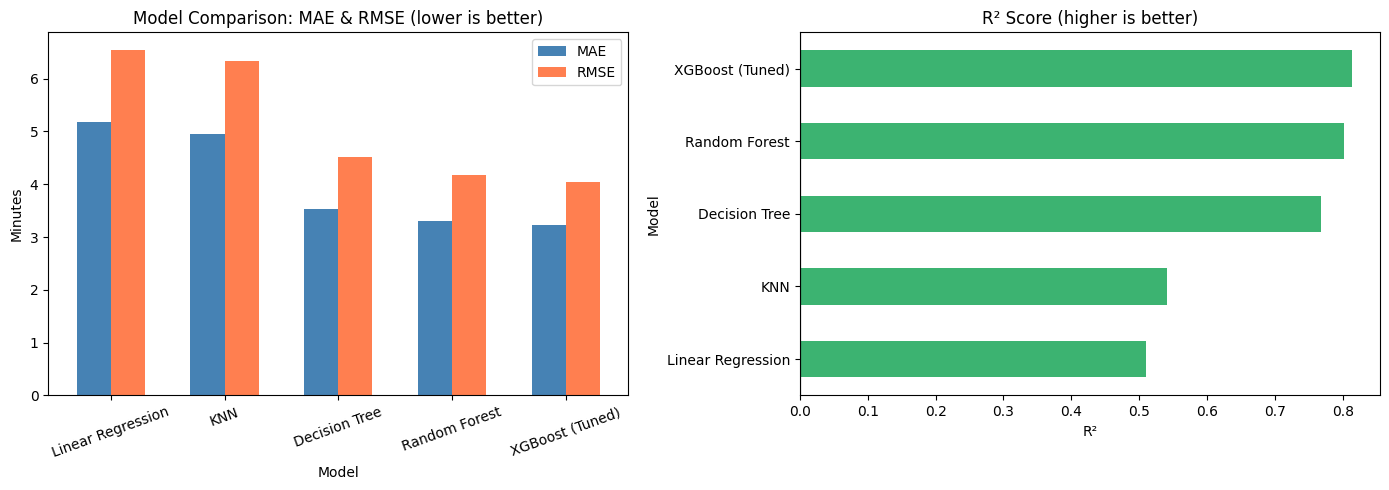

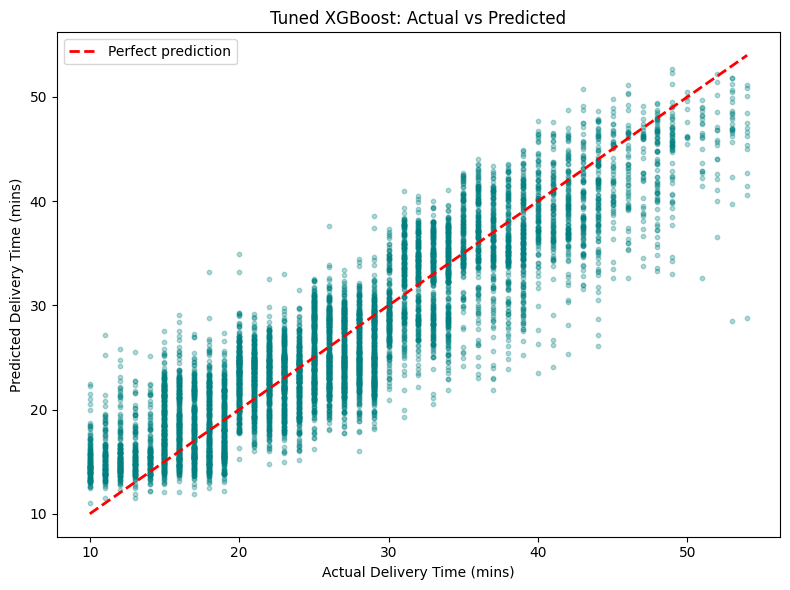

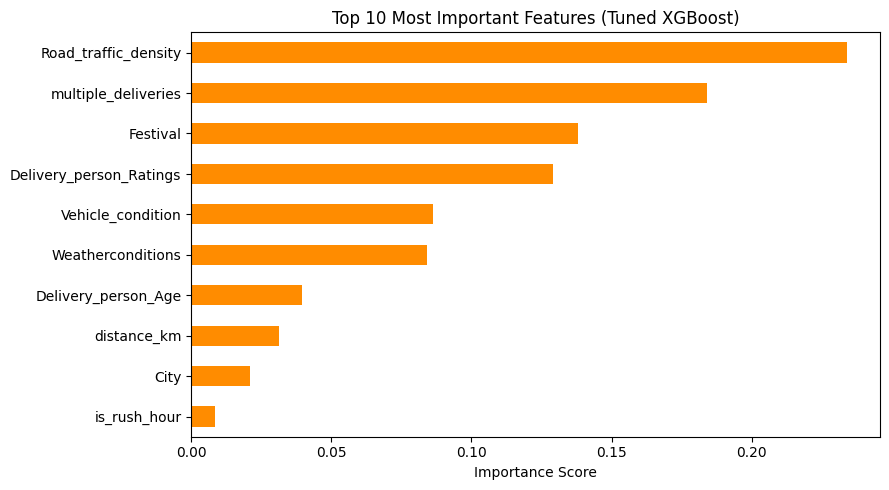

In [17]:
# Plot 1: Full model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_new_df = pd.DataFrame([
    {'Model': 'Linear Regression', 'MAE': 5.17, 'RMSE': 6.55, 'R2': 0.5102},
    {'Model': 'KNN',               'MAE': 4.96, 'RMSE': 6.34, 'R2': 0.5412},
    {'Model': 'Decision Tree',     'MAE': 3.54, 'RMSE': 4.51, 'R2': 0.7679},
    {'Model': 'Random Forest',     'MAE': 3.30, 'RMSE': 4.17, 'R2': 0.8017},
    {'Model': 'XGBoost (Tuned)',   'MAE': 3.23, 'RMSE': 4.04, 'R2': 0.8138},
]).set_index('Model')

results_new_df[['MAE', 'RMSE']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], width=0.6
)
axes[0].set_title('Model Comparison: MAE & RMSE (lower is better)')
axes[0].set_ylabel('Minutes')
axes[0].tick_params(axis='x', rotation=20)

results_new_df['R2'].plot(
    kind='barh', ax=axes[1], color='mediumseagreen'
)
axes[1].set_title('R² Score (higher is better)')
axes[1].set_xlabel('R²')
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Plot 2: Actual vs Predicted (Tuned XGBoost)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.3, color='teal', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Delivery Time (mins)')
plt.ylabel('Predicted Delivery Time (mins)')
plt.title('Tuned XGBoost: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Feature Importance
feat_imp = pd.Series(
    grid_search.best_estimator_.feature_importances_,
    index=X_train.columns
)
feat_imp.nlargest(10).sort_values().plot(
    kind='barh', figsize=(9, 5), color='darkorange'
)
plt.title('Top 10 Most Important Features (Tuned XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 10. Save Model

In [18]:
import joblib

# Save best model and scaler
joblib.dump(grid_search.best_estimator_, 'delivery_time_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Model saved as delivery_time_model.pkl")
print("✅ Scaler saved as scaler.pkl")

# Test loading and predicting
loaded_model = joblib.load('delivery_time_model.pkl')
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)[0]
actual      = y_test.iloc[0]

print(f"\n🚀 Sample Prediction Test:")
print(f"   Predicted : {prediction:.1f} minutes")
print(f"   Actual    : {actual:.1f} minutes")
print(f"   Error     : {abs(prediction - actual):.1f} minutes")

✅ Model saved as delivery_time_model.pkl
✅ Scaler saved as scaler.pkl

🚀 Sample Prediction Test:
   Predicted : 44.9 minutes
   Actual    : 44.0 minutes
   Error     : 0.9 minutes


In [19]:
final_summary = pd.DataFrame([
    {'Model': 'Linear Regression', 'MAE': 5.17, 'RMSE': 6.55, 'R2': 0.5102, 'CV R2': 0.5072},
    {'Model': 'KNN',               'MAE': 4.96, 'RMSE': 6.34, 'R2': 0.5412, 'CV R2': 0.5300},
    {'Model': 'Decision Tree',     'MAE': 3.54, 'RMSE': 4.51, 'R2': 0.7679, 'CV R2': 0.7643},
    {'Model': 'Random Forest',     'MAE': 3.30, 'RMSE': 4.17, 'R2': 0.8017, 'CV R2': 0.7991},
    {'Model': 'XGBoost (Tuned)',   'MAE': 3.23, 'RMSE': 4.04, 'R2': 0.8138, 'CV R2': 0.8141},
]).set_index('Model')

print("=== FINAL PROJECT RESULTS ===")
print(final_summary.sort_values('R2', ascending=False).round(4))

=== FINAL PROJECT RESULTS ===
                    MAE  RMSE      R2   CV R2
Model                                        
XGBoost (Tuned)    3.23  4.04  0.8138  0.8141
Random Forest      3.30  4.17  0.8017  0.7991
Decision Tree      3.54  4.51  0.7679  0.7643
KNN                4.96  6.34  0.5412  0.5300
Linear Regression  5.17  6.55  0.5102  0.5072
